In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv('AQI.csv')
df.head()

,State,County,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days PM2.5,Days PM10
0,Alabama,Baldwin,2025,241,174,67,0,0,0,0,87,56,42,0,0,91,150,0
1,Alabama,Clay,2025,239,204,34,1,0,0,0,133,52,32,0,0,0,239,0
2,Alabama,DeKalb,2025,243,191,52,0,0,0,0,93,55,42,0,0,156,87,0
3,Alabama,Elmore,2025,177,172,5,0,0,0,0,64,46,32,0,0,177,0,0
4,Alabama,Etowah,2025,241,153,88,0,0,0,0,87,58,45,0,0,72,169,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 978 entries, 0 to 977
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   State                                978 non-null    object
 1   County                               978 non-null    object
 2   Year                                 978 non-null    int64 
 3   Days with AQI                        978 non-null    int64 
 4   Good Days                            978 non-null    int64 
 5   Moderate Days                        978 non-null    int64 
 6   Unhealthy for Sensitive Groups Days  978 non-null    int64 
 7   Unhealthy Days                       978 non-null    int64 
 8   Very Unhealthy Days                  978 non-null    int64 
 9   Hazardous Days                       978 non-null    int64 
 10  Max AQI                              978 non-null    int64 
 11  90th Percentile AQI                  978 non-

In [12]:
territories = [
    "Virgin Islands",
    "Country Of Mexico",
    "Puerto Rico",
    "Guam",
    "American Samoa",
    "Northern Mariana Islands"
]

df = df[~df["State"].isin(territories)]

In [13]:
unhealthy_cols = ['Unhealthy for Sensitive Groups Days', 'Unhealthy Days', 'Very Unhealthy Days', 'Hazardous Days']

df['Pct_Unhealthy_Days'] = df[unhealthy_cols].sum(axis=1) * 100 / df['Days with AQI']
df

,State,County,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days PM2.5,Days PM10,Pct_Unhealthy_Days
0,Alabama,Baldwin,2025,241,174,67,0,0,0,0,87,56,42,0,0,91,150,0,0.000000
1,Alabama,Clay,2025,239,204,34,1,0,0,0,133,52,32,0,0,0,239,0,0.418410
2,Alabama,DeKalb,2025,243,191,52,0,0,0,0,93,55,42,0,0,156,87,0,0.000000
3,Alabama,Elmore,2025,177,172,5,0,0,0,0,64,46,32,0,0,177,0,0,0.000000
4,Alabama,Etowah,2025,241,153,88,0,0,0,0,87,58,45,0,0,72,169,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
973,Wyoming,Sublette,2025,242,165,76,1,0,0,0,101,67,47,0,0,240,2,0,0.413223
974,Wyoming,Sweetwater,2025,212,149,59,4,0,0,0,115,64,45,0,0,164,30,18,1.886792
975,Wyoming,Teton,2025,226,179,47,0,0,0,0,84,58,45,2,0,221,3,0,0.000000
976,Wyoming,Uinta,2025,87,87,0,0,0,0,0,50,21,10,0,0,0,0,87,0.000000


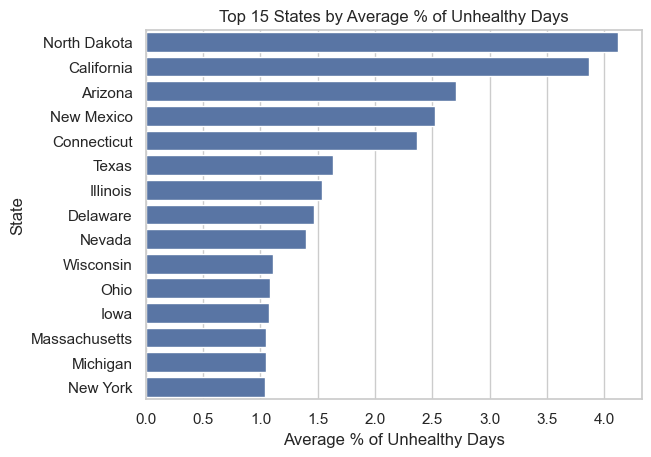

In [14]:
state_summary = (
    df.groupby("State").agg(
          avg_pct_unhealthy = ("Pct_Unhealthy_Days", "mean"),
          avg_max_aqi = ("Max AQI", "mean"),
          avg_90th_aqi = ("90th Percentile AQI", "mean"),
          avg_median_aqi = ("Median AQI", "mean"),

          counties = ("County", "count")
      )
      .sort_values("avg_pct_unhealthy", ascending=False)
)

sns.set_theme(style="whitegrid")

top_n_states = 15

state_plot = (
    state_summary
        .reset_index()
        .sort_values("avg_pct_unhealthy", ascending=False)
        .head(top_n_states)
)

sns.barplot(
    data = state_plot,
    x = "avg_pct_unhealthy",
    y = "State"
)
plt.xlabel("Average % of Unhealthy Days")
plt.ylabel("State")
plt.title(f"Top {top_n_states} States by Average % of Unhealthy Days")
plt.show()

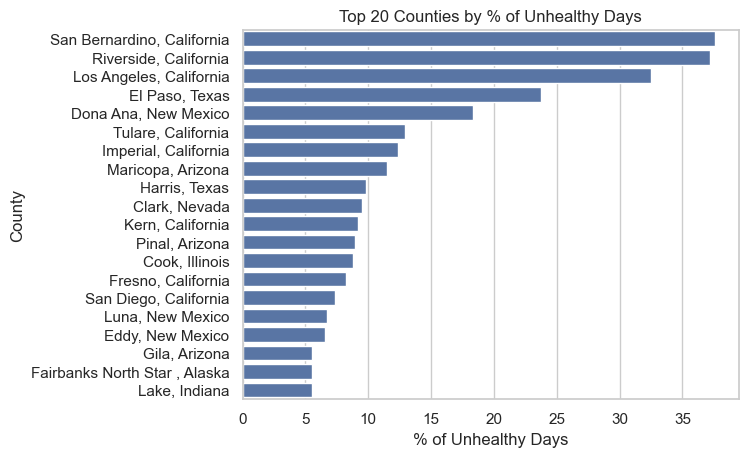

In [15]:
top_n_counties = 20

df["County_State"] = df["County"] + ", " + df["State"]

county_plot = (
    df.sort_values("Pct_Unhealthy_Days", ascending=False)
      .head(top_n_counties)
)

sns.barplot(
    data = county_plot,
    x = "Pct_Unhealthy_Days",
    y = "County_State"
)
plt.xlabel("% of Unhealthy Days")
plt.ylabel("County")
plt.title(f"Top {top_n_counties} Counties by % of Unhealthy Days")
plt.show()